<a href="https://colab.research.google.com/github/Juanma-dev-tech/procesamiento-de-datos/blob/main/Ejercicio%20adicional%20de%20clase%202-%20Exploraci%C3%B3n%20y%20Enriquecimiento/Desempe%C3%B1o_obligatorio_PD_clase_02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Desempeño obligatorio

## 1. Imputación de columnas

In [45]:
import pandas as pd

In [46]:
from google.colab import files
uploaded = files.upload()

Saving Global Missing Migrants Dataset.csv to Global Missing Migrants Dataset.csv


In [47]:
!ls

'Global Missing Migrants Dataset.csv'   sample_data


In [48]:
df = pd.read_csv("Global Missing Migrants Dataset.csv")
df.head()

,Incident Type,Incident year,Reported Month,Region of Origin,Region of Incident,Country of Origin,Number of Dead,Minimum Estimated Number of Missing,Total Number of Dead and Missing,Number of Survivors,Number of Females,Number of Males,Number of Children,Cause of Death,Migration route,Location of death,Information Source,Coordinates,UNSD Geographical Grouping
0,Incident,2014,January,Central America,North America,Guatemala,1.0,0,1,0,0,1,0,Mixed or unknown,US-Mexico border crossing,Pima Country Office of the Medical Examiner ju...,Pima County Office of the Medical Examiner (PC...,"31.650259, -110.366453",Northern America
1,Incident,2014,January,Latin America / Caribbean (P),North America,Unknown,1.0,0,1,0,0,0,0,Mixed or unknown,US-Mexico border crossing,Pima Country Office of the Medical Examiner ju...,Pima County Office of the Medical Examiner (PC...,"31.59713, -111.73756",Northern America
2,Incident,2014,January,Latin America / Caribbean (P),North America,Unknown,1.0,0,1,0,0,0,0,Mixed or unknown,US-Mexico border crossing,Pima Country Office of the Medical Examiner ju...,Pima County Office of the Medical Examiner (PC...,"31.94026, -113.01125",Northern America
3,Incident,2014,January,Central America,North America,Mexico,1.0,0,1,0,0,1,0,Violence,US-Mexico border crossing,"near Douglas, Arizona, USA","Ministry of Foreign Affairs Mexico, Pima Count...","31.506777, -109.315632",Northern America
4,Incident,2014,January,Northern Africa,Europe,Sudan,1.0,0,1,2,0,1,0,Harsh environmental conditions / lack of adequ...,NaN,Border between Russia and Estonia,EUBusiness (Agence France-Presse),"59.1551, 28",Northern Europe


In [49]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13020 entries, 0 to 13019
Data columns (total 19 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   Incident Type                        13020 non-null  object 
 1   Incident year                        13020 non-null  int64  
 2   Reported Month                       13020 non-null  object 
 3   Region of Origin                     12998 non-null  object 
 4   Region of Incident                   13020 non-null  object 
 5   Country of Origin                    13012 non-null  object 
 6   Number of Dead                       12470 non-null  float64
 7   Minimum Estimated Number of Missing  13020 non-null  int64  
 8   Total Number of Dead and Missing     13020 non-null  int64  
 9   Number of Survivors                  13020 non-null  int64  
 10  Number of Females                    13020 non-null  int64  
 11  Number of Males             

## Columna "Number of Dead"

In [50]:
df["Number of Dead"].isna().sum()

np.int64(550)

In [51]:
df[df["Number of Dead"].isna()].sample(10)

,Incident Type,Incident year,Reported Month,Region of Origin,Region of Incident,Country of Origin,Number of Dead,Minimum Estimated Number of Missing,Total Number of Dead and Missing,Number of Survivors,Number of Females,Number of Males,Number of Children,Cause of Death,Migration route,Location of death,Information Source,Coordinates,UNSD Geographical Grouping
11714,Incident,2022,December,Caribbean,Caribbean,Cuba,NaN,18,18,0,4,14,0,Drowning,Caribbean to US,"Habana, Cuba",Homeland Security Task Force-Southeast (HSTF-S...,"23.09382119, -82.458903",Uncategorized
4613,Incident,2018,July,Northern Africa,Mediterranean,Algeria,NaN,3,3,10,0,0,0,Drowning,Western Mediterranean,"Off the coast of Cherchell, Wilaya of Tipasa, ...","El Watan, Algérie Presse Service","36.82736503, 2.019972304",Uncategorized
7933,Incident,2020,October,Northern Africa,Mediterranean,Algeria,NaN,5,5,6,0,5,0,Harsh environmental conditions / lack of adequ...,Central Mediterranean,"They left from Annaba, Algeria on 09.10 and we...","Alarm Phone, Italian Coast Guard","38.52981139, 13.30673754",Uncategorized
12500,Incident,2023,January,Western Asia (P),Europe,Unknown,NaN,1,1,0,0,0,0,Harsh environmental conditions / lack of adequ...,Belarus-EU border,Unspecified location in the wetlands of Easter...,"InfoMigrants, Reuters, Yemen Embassy in German...","52.096721, 23.593233",Eastern Europe
1803,Incident,2016,July,Caribbean,Caribbean,Cuba,NaN,2,2,6,0,0,0,Mixed or unknown,Caribbean to US,"Off the coast of Boca Raton, Florida",WPTV,"26.3700653, -80.0713358",Caribbean
2140,Incident,2016,October,Mixed,Mediterranean,Unknown,NaN,29,29,0,0,0,0,Drowning,Central Mediterranean,Unspecified location between Libya and Italy,IOM Italy,"34.2533716, 14.4988153",Uncategorized
12397,Incident,2022,March,Latin America / Caribbean (P),Central America,Unknown,NaN,10,10,0,0,0,0,Mixed or unknown,Darien,Unspecified location in the Darien National Pa...,Survivor testimony via IOM Panama,"8.443907717, -77.616875",Central America
6555,Incident,2019,September,Northern Africa,Mediterranean,Morocco,NaN,4,4,0,0,4,0,Drowning,Western Mediterranean,"Off the coast of Bouyafar, Morocco (Alboran Sea)","El Faro de Ceuta, EFE, Association Marocaine d...","35.837725415, -3.356083848",Uncategorized
12405,Incident,2022,April,Latin America / Caribbean (P),Central America,Unknown,NaN,4,4,0,0,0,0,Mixed or unknown,Darien,Unspecified location in the Darien National Pa...,Survivor testimony via IOM Panama,"8.443907717, -77.616875",Central America
3463,Incident,2017,October,Caribbean,Caribbean,Cuba,NaN,2,2,4,0,2,0,Drowning,Caribbean to US,"Off the coast of Cayo Caguama, south of Camagü...","14ymedio, Martí Noticias","20.33555265, -78.6853475",Caribbean


### Imputación de la columna "Number of Dead"

Se identificaron valores faltantes en la columna "Number of Dead".
A partir del análisis del dataset, se observó que existe una relación entre las variables
"Total Number of Dead and Missing" y "Minimum Estimated Number of Missing", donde:

Total = Dead + Missing

En los casos analizados, cuando el número de fallecidos no está presente, el total coincide con el número de desaparecidos, lo que indica que no hay muertes confirmadas.

Por lo tanto, se imputaron los valores faltantes utilizando esta relación, evitando introducir valores arbitrarios.

Este caso corresponde a datos faltantes del tipo MAR (Missing At Random).

In [52]:
df["Number of Dead"] = df["Number of Dead"].fillna(
    df["Total Number of Dead and Missing"] - df["Minimum Estimated Number of Missing"]
)

### Verificación

In [53]:
df["Number of Dead"].isna().sum()

np.int64(0)

## Columna "UNSD Geographical Grouping"

In [54]:
df["UNSD Geographical Grouping"].isna().sum()

np.int64(1)

In [55]:
df[df["UNSD Geographical Grouping"].isna()]

,Incident Type,Incident year,Reported Month,Region of Origin,Region of Incident,Country of Origin,Number of Dead,Minimum Estimated Number of Missing,Total Number of Dead and Missing,Number of Survivors,Number of Females,Number of Males,Number of Children,Cause of Death,Migration route,Location of death,Information Source,Coordinates,UNSD Geographical Grouping
5360,Incident,2018,February,Latin America / Caribbean (P),North America,Unknown,1.0,0,1,0,0,1,0,Mixed or unknown,US-Mexico border crossing,Pima Country Office of the Medical Examiner ju...,NaN,"33.061615, -113.367348",NaN


### Imputación de la columna "UNSD Geographical Grouping"

Se identificó un único valor faltante en la columna "UNSD Geographical Grouping".
Al analizar el registro correspondiente, se observó que la variable "Country of Origin" también presenta un valor "Unknown", lo que impide inferir la agrupación geográfica de manera confiable.

Si bien existe una columna "Region of Origin", esta representa una clasificación más amplia y no permite asignar con precisión una categoría de agrupación geográfica según el estándar UNSD.

Por este motivo, se determinó que no es posible imputar el valor a partir de otras variables del dataset.
En consecuencia, se optó por asignar la categoría "Unknown".

Este caso corresponde a datos faltantes del tipo MNAR (Missing Not At Random), ya que la ausencia del dato no puede explicarse mediante otras variables observadas.

In [56]:
df["UNSD Geographical Grouping"] = df["UNSD Geographical Grouping"].fillna("Unknown")

### Verificación

In [57]:
df["UNSD Geographical Grouping"].isna().sum()

np.int64(0)

## Columna "Migration Route"

In [58]:
df["Migration route"].isna().sum()

np.int64(3021)

In [59]:
df[df["Migration route"].isna()].sample(10)

,Incident Type,Incident year,Reported Month,Region of Origin,Region of Incident,Country of Origin,Number of Dead,Minimum Estimated Number of Missing,Total Number of Dead and Missing,Number of Survivors,Number of Females,Number of Males,Number of Children,Cause of Death,Migration route,Location of death,Information Source,Coordinates,UNSD Geographical Grouping
400,Incident,2015,April,Latin America / Caribbean (P),Central America,Unknown,1.0,0,1,0,0,1,0,Vehicle accident / death linked to hazardous t...,NaN,"Rincón de Romos, Aguascalientes, Mexico",Noticiero El Circo,"26.213257, -100.156984",Central America
4263,Incident,2018,May,Eastern Africa (P),Eastern Africa,Unknown,1.0,0,1,0,1,0,0,Violence,NaN,"Near Bossaso, Somalia",Mixed Migration Monitoring Mechanism Initiativ...,"11.275784, 49.121736",Eastern Africa
4461,Incident,2018,June,Sub-Saharan Africa (P),Western Africa,Unknown,1.0,0,1,0,0,1,0,Vehicle accident / death linked to hazardous t...,NaN,"Bamako, Mali",Mixed Migration Monitoring Mechanism Initiativ...,"12.639167, -8.002778",Western Africa
7905,Incident,2020,October,Southern Asia,Europe,Pakistan,1.0,0,1,9,0,1,0,Vehicle accident / death linked to hazardous t...,NaN,"On the old highway of Kavala-Thessaloniki, Eas...",Regional Police Department of East Macedonia/T...,"41.1295126, 24.8877191",Southern Europe
10296,Incident,2022,January,South America,South America,Paraguay,1.0,0,1,0,0,1,0,Violence,NaN,"Río Paraná, Capitán Meza, Itapúa, Paraguay-Arg...","Hoy Paraguay, La Voz de Misiones, ABC Paraguay","-26.94029127, -55.23607685",South America
11919,Incident,2022,August,Southern Asia,Southern Asia,Afghanistan,1.0,0,1,0,0,0,0,Mixed or unknown,NaN,"Gerzewan village, Shirin Tagab district, Farya...",IOM Afghanistan,"36.2382799, 64.8644455",Southern Asia
5121,Incident,2018,October,Eastern Africa (P),Eastern Africa,Unknown,1.0,0,1,0,0,0,0,Sickness / lack of access to adequate healthcare,NaN,"Metema, Ethiopia-Sudan border",Mixed Migration Monitoring Mechanism Initiativ...,"12.953846, 36.152215",Eastern Africa
12505,Incident,2023,January,Northern Africa,Northern Africa,Morocco,1.0,0,1,0,1,0,0,Sickness / lack of access to adequate healthcare,NaN,Unspecified location between Nador and Melilla...,"Dalil Rif, Bladi","35.269076, -2.934889",Northern Africa
11768,Incident,2022,May,Southern Asia,Southern Asia,Afghanistan,1.0,0,1,0,0,1,0,Accidental death,NaN,"Qarloq village, Dasht Archi district, Kunduz p...",IOM Afghanistan,"37.1228583, 69.1581192",Southern Asia
12951,Incident,2023,July,Unknown,Northern Africa,Unknown,2.0,1,3,2,0,0,0,Mixed or unknown,NaN,"Survivors rescued from Boushref, near Al-Assah...",IOM Libya,"32.94655961, 11.532978",Northern Africa


### Imputación de la columna "Migration route"

La columna "Migration route" presenta una cantidad significativa de valores faltantes.
Al analizar el dataset, se observó que no es posible inferir estos valores a partir de otras variables disponibles, ya que la ruta migratoria depende de múltiples factores externos que no están representados en el dataset.

Por lo tanto, se determinó que no existe una alternativa confiable para imputar estos valores a partir de la información disponible.

En consecuencia, se optó por asignar la categoría "Unknown".

Este caso corresponde a datos faltantes del tipo MNAR (Missing Not At Random).

In [60]:
df["Migration route"] = df["Migration route"].fillna("Unknown")

### Verificación

In [61]:
df["Migration route"].isna().sum()

np.int64(0)

## 2. EDA Básico

### Distribución por región

<Axes: xlabel='Region of Incident'>

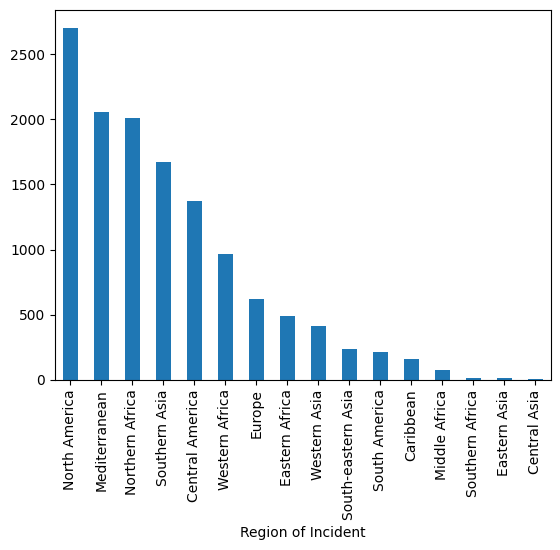

In [62]:
df["Region of Incident"].value_counts().plot(kind="bar")

### Causas de muerte

<Axes: xlabel='Cause of Death'>

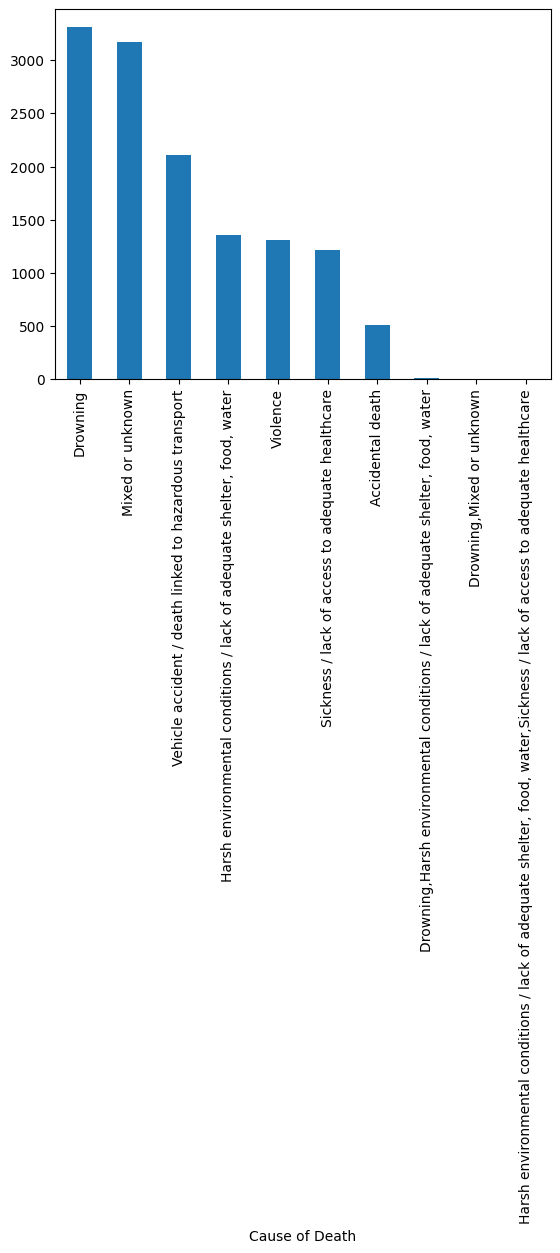

In [63]:
df["Cause of Death"].value_counts().head(10).plot(kind="bar")

### Evolución temporal

<Axes: xlabel='Incident year'>

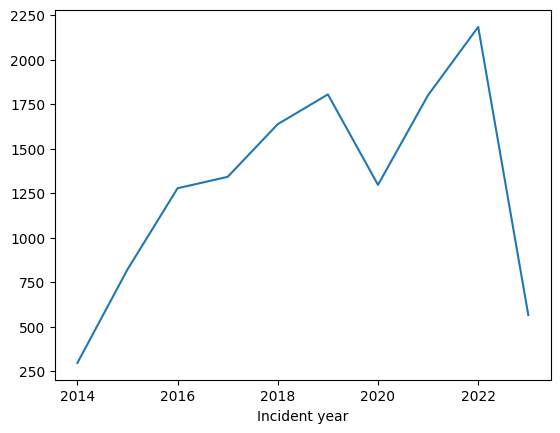

In [64]:
df["Incident year"].value_counts().sort_index().plot()

### Género

<Axes: >

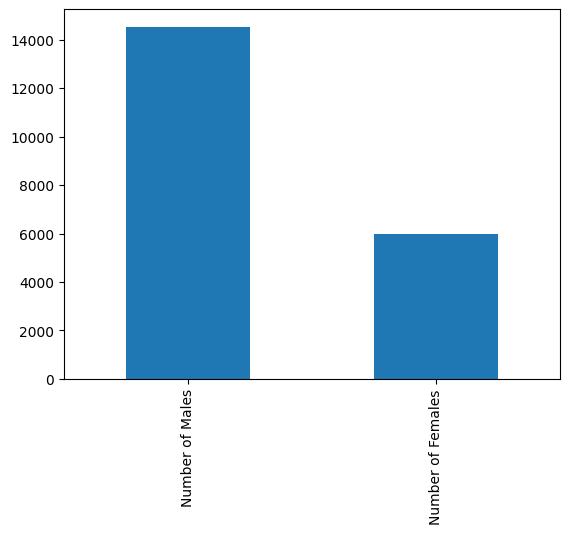

In [65]:
df[["Number of Males", "Number of Females"]].sum().plot(kind="bar")

## Análisis Exploratorio de Datos (EDA)

Se realizó un análisis exploratorio básico con el objetivo de comprender la distribución de los datos.

Se analizaron:
- Distribución de incidentes por región
- Principales causas de muerte
- Evolución temporal de los incidentes
- Distribución por género

Este análisis permite identificar patrones generales y tendencias en el dataset.

## 3. Investigar herramientas

### Herramienta Open Source: Apache Spark

Apache Spark es un framework open source utilizado para el procesamiento distribuido de grandes volúmenes de datos. Permite trabajar con datos estructurados mediante DataFrames y realizar operaciones de transformación y análisis de manera eficiente.

Se destaca por su capacidad de procesamiento en paralelo, lo que permite escalar el análisis de datos en múltiples nodos y reducir significativamente los tiempos de ejecución.

Ejemplo de uso en la vida real:
Empresas como Netflix utilizan Apache Spark para procesar grandes volúmenes de datos relacionados con el comportamiento de los usuarios, lo que les permite generar sistemas de recomendación personalizados.

Además, Spark es ampliamente utilizado en áreas como machine learning, procesamiento de logs y análisis en tiempo real.

### Herramienta Comercial: Snowflake

Snowflake es una plataforma de almacenamiento y procesamiento de datos en la nube (Data Warehouse) que permite gestionar grandes volúmenes de datos estructurados de manera escalable y eficiente.

A diferencia de soluciones tradicionales, Snowflake separa el almacenamiento del cómputo, lo que permite escalar cada componente de forma independiente según las necesidades del negocio.

Ejemplo de uso en la vida real:
Empresas como Coca-Cola utilizan Snowflake para centralizar datos provenientes de múltiples fuentes y realizar análisis en tiempo real, facilitando la toma de decisiones estratégicas basadas en datos.

Snowflake es ampliamente utilizado en entornos empresariales donde se requiere alta disponibilidad, seguridad y rendimiento en el análisis de datos.

### Comparación

Apache Spark es una herramienta open source que requiere configuración e infraestructura propia, pero ofrece gran flexibilidad y control.

Snowflake, en cambio, es una solución comercial gestionada en la nube, que simplifica la implementación y el mantenimiento, a costa de un costo económico.

La elección entre ambas depende del contexto del proyecto, los recursos disponibles y las necesidades de escalabilidad.